# LoRA / QLoRA Fine-tuning Report

Fine-tuning **Qwen2.5-3B** with QLoRA on a Vietnamese instruction dataset. The notebook compares LoRA ranks `r=8`, `r=16`, and `r=64`, then evaluates additional `r=16` variants.

| Component | Value |
|---|---|
| Base model | `unsloth/Qwen2.5-3B-bnb-4bit` |
| Runtime GPU | T4 |
| Train / eval batch | 1 / 1 |
| Gradient accumulation | 8 |
| Max sequence length cap | 1024 |
| Dataset samples | 200 |


## 0. Environment

Runtime was configured with a T4 GPU. Outputs, adapters, metrics, and exported artifacts are saved under `OUTPUT_DIR`.


In [1]:
!nvidia-smi


Thu Jun 25 16:45:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   74C    P8             23W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch

assert torch.cuda.is_available(), (
    "❌ Chưa bật GPU. Colab: Runtime > Change runtime type > Hardware accelerator = T4 GPU."
)
name = torch.cuda.get_device_name(0)
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"✓ GPU: {name}")
print(f"✓ VRAM: {vram_gb:.1f} GB")
print(f"✓ CUDA: {torch.version.cuda}")
print(f"✓ PyTorch: {torch.__version__}")

if vram_gb > 20:
    print("\n⚠️  GPU lớn (>20GB VRAM, vd A100/L4). Chạy được nhưng underutilized — có thể tăng batch size.")
elif 'T4' not in name:
    print(f"\n💡 Notebook tối ưu cho T4 (16GB). GPU của bạn ({name}) vẫn chạy được.")

✓ GPU: Tesla T4
✓ VRAM: 15.6 GB
✓ CUDA: 12.8
✓ PyTorch: 2.11.0+cu128


In [3]:
%%capture
!pip install -q --upgrade pip
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install -q --no-deps "trl>=0.12,<0.16" peft accelerate bitsandbytes
!pip install -q datasets matplotlib seaborn pandas wandb huggingface_hub

In [4]:
MOUNT_DRIVE = True

import os
if MOUNT_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUTPUT_DIR = '/content/drive/MyDrive/lab21_lora_t4'
elif os.path.exists('/content'):
    OUTPUT_DIR = '/content/lab21_lora_t4'
elif os.path.exists('/kaggle'):
    OUTPUT_DIR = '/kaggle/working/lab21_lora_t4'
else:
    OUTPUT_DIR = os.path.abspath('./lab21_lora_t4')

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✓ Output dir: {OUTPUT_DIR}")

Mounted at /content/drive
✓ Output dir: /content/drive/MyDrive/lab21_lora_t4


In [5]:
import os
USE_WANDB = True
WANDB_PROJECT = "lab21-lora-rank"
if USE_WANDB:
    import wandb
    key = os.environ.get("WANDB_API_KEY")
    if key is None:
        try:
            from google.colab import userdata
            key = userdata.get("WANDB_API_KEY")
        except Exception:
            key = None
    wandb.login(key=key) if key else wandb.login()
    os.environ["WANDB_PROJECT"] = WANDB_PROJECT
    print(f"✓ W&B ON → project '{WANDB_PROJECT}'. make_trainer() sẽ tự report_to='wandb'.")
else:
    print("ℹ️ W&B logging disabled.")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nglyminhky2k4 (nglyminhky2k4-nknk) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✓ W&B ON → project 'lab21-lora-rank'. make_trainer() sẽ tự report_to='wandb'.


## 1. Dataset Preparation

The experiment uses a Vietnamese Alpaca-format instruction dataset and maps the instruction/input/output columns into a single supervised fine-tuning text field.


In [6]:
from datasets import load_dataset

raw = load_dataset("5CD-AI/Vietnamese-alpaca-gpt4-gg-translated", split="train")
raw = raw.shuffle(seed=42).select(range(200))
print(f"✓ Loaded {len(raw)} samples")
print(f"✓ Columns: {raw.column_names}")
print("\n--- Sample 0 ---")
print(raw[0])

✓ Loaded 200 samples
✓ Columns: ['input_en', 'input_vi', 'instruction_vi', 'output_vi', 'output_en', 'instruction_en']

--- Sample 0 ---
{'input_en': '', 'input_vi': '', 'instruction_vi': 'Tạo ngân sách cơ bản cho người kiếm được 3500 đô la mỗi tháng.', 'output_vi': 'Dựa trên thu nhập 3500 USD mỗi tháng, đây là ngân sách cơ bản được đề xuất tuân theo quy tắc 50/30/20, phân bổ 50% thu nhập cho nhu cầu, 30% cho mong muốn và 20% cho tiết kiệm và trả nợ: - Tổng thu nhập hàng tháng: $3500 - Nhu cầu (50% thu nhập): $1750 - Nhà ở (tiền thuê nhà/thế chấp): $875 - Tiện ích (điện, nước, gas): $150 - Hàng tạp hóa: $300 - Bảo hiểm (sức khỏe, xe hơi, người thuê nhà, v.v. ): $200 - Đi lại (thanh toán ô tô, xăng, phương tiện công cộng): $225 - Mong muốn (30% thu nhập): $1050 - Ăn uống và giải trí: $300 - Chi phí mua sắm và cá nhân: $300 - Du lịch và sở thích: $250 - Linh tinh (đăng ký , thành viên): $200 - Tiết kiệm và trả nợ (20% thu nhập): $700 - Quỹ khẩn cấp: $200 - Quỹ hưu trí: $300 - Trả nợ (thẻ

In [8]:
# Detect dataset columns.
cols = raw.column_names
INSTRUCTION_COL = next((c for c in ["instruction","instruction_vi","prompt","question"] if c in cols), None)
INPUT_COL       = next((c for c in ["input","input_vi","context"] if c in cols), None)
OUTPUT_COL      = next((c for c in ["output","output_vi","response","answer"] if c in cols), None)
assert INSTRUCTION_COL and OUTPUT_COL, f"Không tìm thấy cột instruction/output trong: {cols}"
print(f"✓ Cột dùng: instruction='{INSTRUCTION_COL}', input='{INPUT_COL}', output='{OUTPUT_COL}'")

ALPACA_TEMPLATE = """### Instruction:
{instruction}

### Input:
{input}

### Response:
{output}"""

ALPACA_TEMPLATE_NO_INPUT = """### Instruction:
{instruction}

### Response:
{output}"""

def format_alpaca(example):
    inp = example.get(INPUT_COL, "") if INPUT_COL else ""
    inp = inp or ""
    if inp.strip():
        text = ALPACA_TEMPLATE.format(
            instruction=example[INSTRUCTION_COL], input=inp,
            output=example[OUTPUT_COL])
    else:
        text = ALPACA_TEMPLATE_NO_INPUT.format(
            instruction=example[INSTRUCTION_COL],
            output=example[OUTPUT_COL])
    return {"text": text}

ds = raw.map(format_alpaca, remove_columns=raw.column_names)
print("\n--- Formatted sample ---")
print(ds[0]["text"][:500])

✓ Cột dùng: instruction='instruction_vi', input='input_vi', output='output_vi'

--- Formatted sample ---
### Instruction:
Tạo ngân sách cơ bản cho người kiếm được 3500 đô la mỗi tháng.

### Response:
Dựa trên thu nhập 3500 USD mỗi tháng, đây là ngân sách cơ bản được đề xuất tuân theo quy tắc 50/30/20, phân bổ 50% thu nhập cho nhu cầu, 30% cho mong muốn và 20% cho tiết kiệm và trả nợ: - Tổng thu nhập hàng tháng: $3500 - Nhu cầu (50% thu nhập): $1750 - Nhà ở (tiền thuê nhà/thế chấp): $875 - Tiện ích (điện, nước, gas): $150 - Hàng tạp hóa: $300 - Bảo hiểm (sức khỏe, xe hơi, người thuê nhà, v.v. ): $20


Token length distribution:
  min=25, max=738
  p50=227, p95=562, p99=704

✓ Chọn max_seq_length = 1024 (cap = 1024)


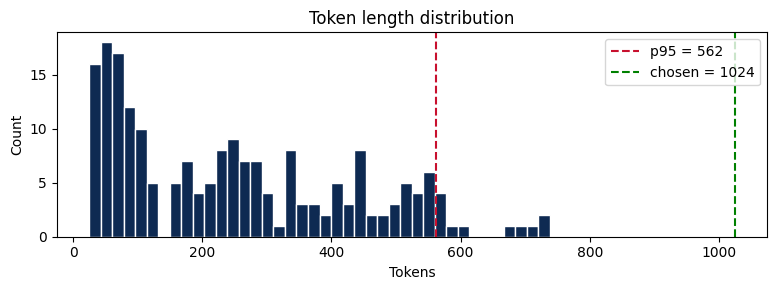

In [9]:
# Analyze token lengths.
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

MODEL_NAME = "unsloth/Qwen2.5-3B-bnb-4bit"
MAX_SEQ_CAP = 1024  # hard cap cho profile T4

tok = AutoTokenizer.from_pretrained(MODEL_NAME)
lengths = [len(tok.encode(x["text"])) for x in ds]

p50 = int(np.percentile(lengths, 50))
p95 = int(np.percentile(lengths, 95))
p99 = int(np.percentile(lengths, 99))

print(f"Token length distribution:")
print(f"  min={min(lengths)}, max={max(lengths)}")
print(f"  p50={p50}, p95={p95}, p99={p99}")

# Choose a rounded sequence length under the configured cap.
MAX_SEQ_LENGTH = min(MAX_SEQ_CAP, 1 << (max(p95, 256) - 1).bit_length())
print(f"\n✓ Chọn max_seq_length = {MAX_SEQ_LENGTH} (cap = {MAX_SEQ_CAP})")

plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=40, color='#0E2A52', edgecolor='white')
plt.axvline(p95, color='#C8102E', linestyle='--', label=f'p95 = {p95}')
plt.axvline(MAX_SEQ_LENGTH, color='green', linestyle='--', label=f'chosen = {MAX_SEQ_LENGTH}')
plt.xlabel('Tokens'); plt.ylabel('Count'); plt.title('Token length distribution')
plt.legend(); plt.tight_layout(); plt.show()

In [10]:
split = ds.train_test_split(test_size=0.1, seed=42)
train_ds = split["train"]
eval_ds = split["test"]
print(f"✓ Train: {len(train_ds)}  |  Eval: {len(eval_ds)}")

✓ Train: 180  |  Eval: 20


## 2. Load Model + Configure LoRA

The base model is loaded in 4-bit quantized form with Unsloth. The baseline adapter uses rank `r=16`, `lora_alpha=32`, and target modules `q_proj`/`v_proj`.


In [11]:
from unsloth import FastLanguageModel

def load_base_model():
    """Reload base model — gọi mỗi lần train với rank khác để start từ scratch."""
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=MODEL_NAME,
        max_seq_length=MAX_SEQ_LENGTH,
        dtype=None,            # auto: bf16 trên Ampere+, fp16 trên T4
        load_in_4bit=True,     # QLoRA
    )
    return model, tokenizer

def wrap_with_lora(model, r, alpha, target_modules=None, use_dora=False):
    """Apply a PEFT LoRA adapter to the base model."""
    return FastLanguageModel.get_peft_model(
        model,
        r=r,
        lora_alpha=alpha,
        target_modules=target_modules or ["q_proj", "v_proj"],
        lora_dropout=0,
        bias="none",
        use_gradient_checkpointing="unsloth",
        use_dora=use_dora,
        random_state=42,
    )

base_model, tokenizer = load_base_model()
model = wrap_with_lora(base_model, r=16, alpha=32)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"\n✓ Trainable: {trainable:,} ({100*trainable/total:.3f}% of {total:,})")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/usr/local/lib/python3.12/dist-packages/unsloth/__init__.py:153: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Could not find `steps_per_generation` in grpo_trainer
Unsloth: Could not find `generation_batch_size` in grpo_trainer
==((====))==  Unsloth 2026.6.9: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Not an error, but Unsloth cannot patch O projection layer with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2026.6.9 patched 36 layers with 36 QKV layers, 0 O layers and 0 MLP layers.



✓ Trainable: 3,686,400 (0.217% of 1,702,359,040)


## 3. Train Baseline (`r=16`)

The baseline run uses 3 epochs, cosine learning-rate schedule, effective batch size 8, and post-training evaluation.


In [12]:
from trl import SFTTrainer
from transformers import TrainingArguments, Trainer
import inspect, time, trl, transformers

print(f"trl: {trl.__version__}  |  transformers: {transformers.__version__}")

# Compatibility shim for TRL/Transformers argument naming.
import unsloth.models._utils as _u_utils
_underlying_init = getattr(_u_utils, "_original_trainer_init", Trainer.__init__)
if not getattr(_underlying_init, "_aliased", False):
    def _aliased_trainer_init(self, *args, **kwargs):
        if "tokenizer" in kwargs and "processing_class" not in kwargs:
            kwargs["processing_class"] = kwargs.pop("tokenizer")
        return _underlying_init(self, *args, **kwargs)
    _aliased_trainer_init._aliased = True
    _u_utils._original_trainer_init = _aliased_trainer_init
    if "tokenizer" not in inspect.signature(Trainer.__init__).parameters:
        _orig_t = Trainer.__init__
        def _t_init(self, *args, **kwargs):
            if "tokenizer" in kwargs and "processing_class" not in kwargs:
                kwargs["processing_class"] = kwargs.pop("tokenizer")
            return _orig_t(self, *args, **kwargs)
        _t_init._aliased = True
        Trainer.__init__ = _t_init
    print("✓ Trainer.__init__ patched")

try:
    from trl import SFTConfig
    _HAS_SFTCONFIG = True
except ImportError:
    _HAS_SFTCONFIG = False

_TA_PARAMS = inspect.signature(TrainingArguments.__init__).parameters
_EVAL_KEY = "eval_strategy" if "eval_strategy" in _TA_PARAMS else "evaluation_strategy"
_SFT_PARAMS = inspect.signature(SFTTrainer.__init__).parameters
_SUPPORTS_OLD_KWARGS = "dataset_text_field" in _SFT_PARAMS

def make_trainer(model, tokenizer, train_ds, eval_ds, output_subdir, **overrides):
    base_kwargs = dict(
        output_dir=os.path.join(OUTPUT_DIR, output_subdir),
        per_device_train_batch_size=1,
        per_device_eval_batch_size=1,
        eval_accumulation_steps=4,
        prediction_loss_only=True,
        gradient_accumulation_steps=8,
        warmup_ratio=0.10,
        num_train_epochs=3,
        learning_rate=2e-4,
        lr_scheduler_type="cosine",
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=5,
        eval_steps=25,
        save_strategy="epoch",
        optim="adamw_8bit",
        weight_decay=0.01,
        seed=42,
        report_to=("wandb" if globals().get("USE_WANDB") else "none"),
    )
    base_kwargs[_EVAL_KEY] = "no"
    base_kwargs.update(overrides)

    if _HAS_SFTCONFIG:
        sft_extra = dict(dataset_text_field="text", packing=False, max_seq_length=MAX_SEQ_LENGTH)
        sft_params = inspect.signature(SFTConfig.__init__).parameters
        sft_extra = {k: v for k, v in sft_extra.items() if k in sft_params}
        valid_base = {k: v for k, v in base_kwargs.items() if k in sft_params}
        args = SFTConfig(**valid_base, **sft_extra)
    else:
        args = TrainingArguments(**base_kwargs)

    trainer_kwargs = {
        "model": model, "train_dataset": train_ds, "eval_dataset": eval_ds, "args": args,
    }
    if "processing_class" in _SFT_PARAMS:
        trainer_kwargs["processing_class"] = tokenizer
    else:
        trainer_kwargs["tokenizer"] = tokenizer
    if _SUPPORTS_OLD_KWARGS:
        trainer_kwargs.update(dict(dataset_text_field="text", max_seq_length=MAX_SEQ_LENGTH, packing=False))
    return SFTTrainer(**trainer_kwargs)

def safe_evaluate(trainer):
    """Evaluate with a manual fallback for runtime or memory failures."""
    import gc as _gc
    _gc.collect(); torch.cuda.empty_cache()

    # Remove the notebook progress callback before evaluation.
    try:
        from transformers.utils.notebook import NotebookProgressCallback
        trainer.remove_callback(NotebookProgressCallback)
    except Exception:
        pass

    # Try standard evaluation first.
    try:
        return trainer.evaluate()["eval_loss"]
    except (torch.cuda.OutOfMemoryError, RuntimeError) as e:
        print(f"⚠ trainer.evaluate() failed ({type(e).__name__}). Falling back to manual eval...")

    # Manual evaluation fallback.
    _gc.collect(); torch.cuda.empty_cache()
    m = trainer.model
    m.eval()
    eval_dl = trainer.get_eval_dataloader()
    total, n = 0.0, 0
    with torch.no_grad():
        for batch in eval_dl:
            batch = {k: v.to(m.device) for k, v in batch.items() if hasattr(v, "to")}
            out = m(**batch)
            total += out.loss.item(); n += 1
            del out; torch.cuda.empty_cache()
    return total / max(n, 1)

trl: 0.15.2  |  transformers: 5.5.0
✓ Trainer.__init__ patched


In [13]:
# Train baseline r=16
import gc
torch.cuda.reset_peak_memory_stats()
trainer_16 = make_trainer(model, tokenizer, train_ds, eval_ds, "r16")

t0 = time.time()
result_16 = trainer_16.train()
wall_16 = time.time() - t0
vram_16 = torch.cuda.max_memory_allocated() / 1e9

print(f"\n✓ r=16 done in {wall_16/60:.1f} min, peak VRAM = {vram_16:.1f} GB")
trainer_16.save_model(os.path.join(OUTPUT_DIR, "r16"))

# Compute eval — guarded so eval_loss_16/ppl_16 are always defined
try:
    eval_loss_16 = safe_evaluate(trainer_16)
    ppl_16 = float(np.exp(eval_loss_16))
    print(f"✓ r=16 eval loss = {eval_loss_16:.4f}, perplexity = {ppl_16:.2f}")
except Exception as e:
    print(f"⚠ Eval failed: {e}. Setting NaN — recover later by reloading adapter.")
    eval_loss_16 = float("nan")
    ppl_16 = float("nan")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 180 | Num Epochs = 3 | Total steps = 69
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 3,686,400 of 3,089,625,088 (0.12% trained)


wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
5,1.614305
10,1.573560
15,1.606689
20,1.555441
25,1.479080
30,1.416185
35,1.496181
40,1.480136
45,1.380218
50,1.388354


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4/r16/checkpoint-23/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4/r16/checkpoint-46/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4/r16/checkpoint-69/tokenizer_config.json.



✓ r=16 done in 5.2 min, peak VRAM = 6.6 GB


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4/r16/tokenizer_config.json.
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


✓ r=16 eval loss = 1.5161, perplexity = 4.55


✓ Saved loss curve → /content/drive/MyDrive/lab21_lora_t4/loss_curve.png


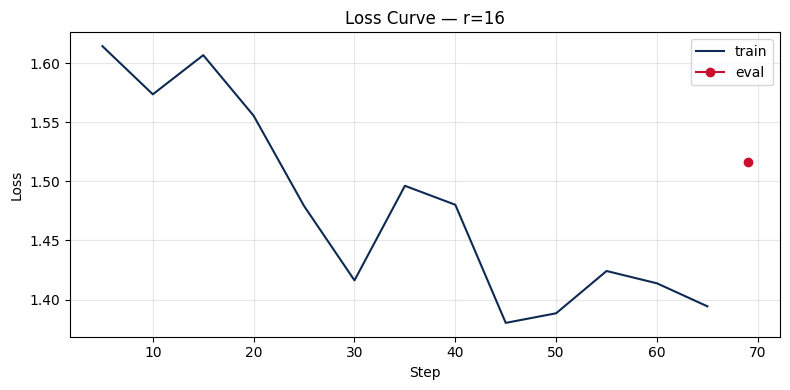


📌 T4 mode: eval-during-training tắt để tiết kiệm VRAM. Chỉ có train loss curve.


In [14]:
# Plot training loss and save it under OUTPUT_DIR.
import pandas as pd

def plot_losses(log_history, title="Training Loss", save_path=None):
    df = pd.DataFrame(log_history)
    train = df[df["loss"].notna()] if "loss" in df else pd.DataFrame()
    eval_ = df[df["eval_loss"].notna()] if "eval_loss" in df else pd.DataFrame()
    plt.figure(figsize=(8, 4))
    if not train.empty:
        plt.plot(train["step"], train["loss"], label="train", color="#0E2A52")
    if not eval_.empty:
        plt.plot(eval_["step"], eval_["eval_loss"], label="eval", color="#C8102E", marker="o")
    plt.xlabel("Step"); plt.ylabel("Loss"); plt.title(title)
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
        print(f"✓ Saved loss curve → {save_path}")
    plt.show()

plot_losses(trainer_16.state.log_history, title="Loss Curve — r=16",
            save_path=os.path.join(OUTPUT_DIR, "loss_curve.png"))
print("\n📌 T4 mode: eval-during-training tắt để tiết kiệm VRAM. Chỉ có train loss curve.")

## 4. Rank Experiment

Additional adapters are trained with `r=8` and `r=64` to compare trainable parameters, VRAM, training time, and perplexity.


In [15]:
def train_one_rank(r, alpha, target_modules=None, use_dora=False, tag=None):
    """Train a fresh adapter and return metrics."""
    subdir = tag or f"r{r}"
    gc.collect(); torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    base_m, tok = load_base_model()
    m = wrap_with_lora(base_m, r=r, alpha=alpha,
                       target_modules=target_modules, use_dora=use_dora)
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)

    tr = make_trainer(m, tok, train_ds, eval_ds, subdir)
    t0 = time.time()
    tr.train()
    wall = time.time() - t0
    vram = torch.cuda.max_memory_allocated() / 1e9

    # Save adapter BEFORE eval — eval may OOM but we want the checkpoint
    tr.save_model(os.path.join(OUTPUT_DIR, subdir))
    print(f"✓ {subdir} adapter saved. Computing eval loss...")

    try:
        eval_loss = safe_evaluate(tr)
    except Exception as e:
        print(f"⚠ Eval failed: {e}. Setting eval_loss=NaN.")
        eval_loss = float('nan')

    return {
        "rank": r, "alpha": alpha, "tag": subdir, "trainable_params": trainable,
        "train_time_min": wall / 60, "peak_vram_gb": vram,
        "eval_loss": eval_loss,
        "eval_perplexity": float(np.exp(eval_loss)) if not np.isnan(eval_loss) else float('nan'),
        "trainer": tr, "model": m, "tokenizer": tok,
    }

In [16]:
# Cleanup baseline before training rank experiments
del trainer_16, model, base_model
gc.collect(); torch.cuda.empty_cache()

print("\n========== Training r=8 ==========")
exp_8 = train_one_rank(r=8, alpha=16)


========== Training r=8 ==========
==((====))==  Unsloth 2026.6.9: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 180 | Num Epochs = 3 | Total steps = 69
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 1,843,200 of 3,087,781,888 (0.06% trained)


Step,Training Loss
5,1.616500
10,1.591786
15,1.633090
20,1.581143
25,1.512532
30,1.451584
35,1.532159
40,1.516283
45,1.417545
50,1.441451


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4/r8/checkpoint-23/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4/r8/checkpoint-46/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4/r8/checkpoint-69/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4/r8/tokenizer_config.json.


✓ r8 adapter saved. Computing eval loss...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


In [17]:
# Cleanup r=8 references
del exp_8["trainer"], exp_8["model"]
gc.collect(); torch.cuda.empty_cache()

print("\n========== Training r=64 ==========")
exp_64 = train_one_rank(r=64, alpha=128)


========== Training r=64 ==========
==((====))==  Unsloth 2026.6.9: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 180 | Num Epochs = 3 | Total steps = 69
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 14,745,600 of 3,100,684,288 (0.48% trained)


Step,Training Loss
5,1.601615
10,1.524071
15,1.547107
20,1.504727
25,1.425420
30,1.345464
35,1.402454
40,1.381225
45,1.297632
50,1.270547


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4/r64/checkpoint-23/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4/r64/checkpoint-46/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4/r64/checkpoint-69/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4/r64/tokenizer_config.json.


✓ r64 adapter saved. Computing eval loss...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


In [18]:
# Cleanup r=64 references
del exp_64["trainer"], exp_64["model"]
gc.collect(); torch.cuda.empty_cache()

# Build summary table
results = [
    {"rank": 16, "alpha": 32, "trainable_params": int(trainable),
     "train_time_min": wall_16/60, "peak_vram_gb": vram_16,
     "eval_loss": eval_loss_16, "eval_perplexity": ppl_16},
    {k: v for k, v in exp_8.items() if k not in ("trainer","model","tokenizer")},
    {k: v for k, v in exp_64.items() if k not in ("trainer","model","tokenizer")},
]
summary_df = pd.DataFrame(results).sort_values("rank").reset_index(drop=True)
print("\n=== Rank Experiment Summary ===")
print(summary_df.to_string(index=False))


=== Rank Experiment Summary ===
 rank  alpha  trainable_params  train_time_min  peak_vram_gb  eval_loss  eval_perplexity tag
    8     16           1843200        4.213949      7.216138   1.557694         4.747861  r8
   16     32           3686400        5.195630      6.617750   1.516083         4.554351 NaN
   64    128          14745600        4.277152      7.998512   1.476815         4.378976 r64


In [19]:
# Evaluate the original base model on the same eval split.
# A no-op LoRA adapter lets Trainer run on the quantized model while preserving base outputs.
gc.collect(); torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

base_only, base_tok = load_base_model()
base_noop = wrap_with_lora(base_only, r=8, alpha=16)
base_eval_trainer = make_trainer(base_noop, base_tok, train_ds, eval_ds, "base_eval")
base_eval_loss = safe_evaluate(base_eval_trainer)
base_ppl = float(np.exp(base_eval_loss))
print(f"✓ Base (no LoRA) eval loss = {base_eval_loss:.4f}, perplexity = {base_ppl:.2f}")

del base_eval_trainer, base_noop, base_only
gc.collect(); torch.cuda.empty_cache()

# Add the base row to the comparison table.
base_row = {"rank": "base", "alpha": None, "trainable_params": 0,
            "train_time_min": float("nan"), "peak_vram_gb": float("nan"),
            "eval_loss": base_eval_loss, "eval_perplexity": base_ppl}
summary_df = pd.concat([summary_df, pd.DataFrame([base_row])], ignore_index=True)
print("\n=== Summary + Base ===")
print(summary_df.to_string(index=False))

==((====))==  Unsloth 2026.6.9: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


✓ Base (no LoRA) eval loss = 1.8666, perplexity = 6.47

=== Summary + Base ===
rank alpha  trainable_params  train_time_min  peak_vram_gb  eval_loss  eval_perplexity tag
   8    16           1843200        4.213949      7.216138   1.557694         4.747861  r8
  16    32           3686400        5.195630      6.617750   1.516083         4.554351 NaN
  64   128          14745600        4.277152      7.998512   1.476815         4.378976 r64
base  None                 0             NaN           NaN   1.866577         6.466126 NaN


## 5. Evaluation

Qualitative prompts compare the base model and the fine-tuned adapter.


In [20]:
TEST_PROMPTS = [
    "Giải thích khái niệm machine learning cho người mới bắt đầu.",
    "Viết đoạn code Python tính số Fibonacci thứ n.",
    "Liệt kê 5 nguyên tắc thiết kế UI/UX.",
    "Tóm tắt sự khác biệt giữa LoRA và QLoRA.",
    "Phân biệt prompt engineering, RAG, và fine-tuning.",
    "Khi nào nên dùng RAG thay vì fine-tuning?",
    "Giải thích cách hoạt động của Flash Attention.",
    "List 3 câu hỏi phỏng vấn cho ML Engineer junior.",
    "Cho biết ưu điểm của Transformer so với RNN.",
    "Cách evaluate performance của một LLM fine-tuned model?",
]
print(f"✓ {len(TEST_PROMPTS)} test prompts")

✓ 10 test prompts


In [21]:
from peft import PeftModel

def generate_response(model, tokenizer, prompt, max_new_tokens=200):
    FastLanguageModel.for_inference(model)
    text = ALPACA_TEMPLATE_NO_INPUT.format(instruction=prompt, output="")
    inputs = tokenizer(text, return_tensors="pt").to("cuda")
    out = model.generate(**inputs, max_new_tokens=max_new_tokens,
        temperature=0.7, top_p=0.9, do_sample=True,
        pad_token_id=tokenizer.eos_token_id)
    full = tokenizer.decode(out[0], skip_special_tokens=True)
    return full.split("### Response:")[-1].strip()

# Reload base + r=16 adapter
base_for_eval, tok_for_eval = load_base_model()
ft_model = PeftModel.from_pretrained(base_for_eval, os.path.join(OUTPUT_DIR, "r16"))

qualitative_results = []
for i, prompt in enumerate(TEST_PROMPTS[:5]):
    print(f"\n━━━ Prompt {i+1}: {prompt[:80]}...")
    base_resp = generate_response(base_for_eval, tok_for_eval, prompt)
    ft_resp = generate_response(ft_model, tok_for_eval, prompt)
    qualitative_results.append({
        "prompt": prompt, "base": base_resp[:300], "finetuned": ft_resp[:300],
    })
    print(f"  BASE: {base_resp[:200]}...")
    print(f"  FT  : {ft_resp[:200]}...")

==((====))==  Unsloth 2026.6.9: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



━━━ Prompt 1: Giải thích khái niệm machine learning cho người mới bắt đầu....


...

  BASE: 1. Thân thiện với người dùng: Mục đích của thiết kế UI/UX là cung cấp trải nghiệm người dùng thân thiện, dễ sử dụng và thân thiện. Điều này có thể được thể hiện thông qua việc sắp xếp bố cục, màu sắc,...
  FT  : 1. Chuyển đổi: UI/UX thiết kế phải hướng tới việc giúp người dùng thực hiện hành động. 2. Thích ứng: UI/UX thiết kế phải thích ứng với nhiều loại thiết bị và kích thước màn hình. 3. Đơn giản: UI/UX th...

━━━ Prompt 4: Tóm tắt sự khác biệt giữa LoRA và QLoRA....


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  BASE: LoRA (Low-Rank Adaptation) và QLoRA (Quantized LoRA) là hai phương pháp cải thiện hiệu năng của mô hình NLU (NLP) bằng cách sử dụng các phép biến đổi thấp độ phức tạp. LoRA là phương pháp cải thiện hi...
  FT  : LoRA (Layer-wise Adaptive Regularization Optimization) và QLoRA (Quantized LoRA) là hai phương pháp regularization được phát triển để cải thiện hiệu quả và độ ổn định của các mạng neural network trong...

━━━ Prompt 5: Phân biệt prompt engineering, RAG, và fine-tuning....


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  BASE: Prompt engineering, RAG (retrieval augmented generation), và fine-tuning là ba cách khác nhau để cải thiện hiệu suất của mô hình máy học. Prompt engineering là một kỹ thuật để cải thiện hiệu suất của ...
  FT  : Prompt engineering, RAG và fine-tuning là ba kỹ thuật khác nhau được sử dụng trong lĩnh vực AI và tự động hóa. Prompt engineering là một kỹ thuật tập trung vào việc xây dựng câu lệnh (prompt) để giúp ...


In [22]:
qual_df = pd.DataFrame(qualitative_results)
qual_df.to_csv(os.path.join(OUTPUT_DIR, "qualitative_comparison.csv"), index=False)
print(qual_df.head())

                                              prompt  \
0  Giải thích khái niệm machine learning cho ngườ...   
1     Viết đoạn code Python tính số Fibonacci thứ n.   
2               Liệt kê 5 nguyên tắc thiết kế UI/UX.   
3           Tóm tắt sự khác biệt giữa LoRA và QLoRA.   
4  Phân biệt prompt engineering, RAG, và fine-tun...   

                                                base  \
0  Machine learning là một phân khúc của trí tuệ ...   
1  Để tính số Fibonacci thứ n, bạn có thể sử dụng...   
2  1. Thân thiện với người dùng: Mục đích của thi...   
3  LoRA (Low-Rank Adaptation) và QLoRA (Quantized...   
4  Prompt engineering, RAG (retrieval augmented g...   

                                           finetuned  
0  Machine learning là một bộ môn công nghệ máy t...  
1  Để tính số Fibonacci thứ n, bạn có thể viết mộ...  
2  1. Chuyển đổi: UI/UX thiết kế phải hướng tới v...  
3  LoRA (Layer-wise Adaptive Regularization Optim...  
4  Prompt engineering, RAG và fine-tuning là ba k..

## 6. Save Adapters + Generate Report

In [23]:
summary_df.to_csv(os.path.join(OUTPUT_DIR, "rank_experiment_summary.csv"), index=False)

GPU_COST_USD_PER_HOUR = 0.35  # T4 default
total_minutes = summary_df["train_time_min"].sum()
total_cost = (total_minutes / 60) * GPU_COST_USD_PER_HOUR

print(f"\n✓ Tổng training time: {total_minutes:.1f} phút")
print(f"✓ Estimated cost: ${total_cost:.2f} (@ ${GPU_COST_USD_PER_HOUR}/hr)")


✓ Tổng training time: 13.7 phút
✓ Estimated cost: $0.08 (@ $0.35/hr)


In [26]:

PUSH_TO_HUB = True
HUB_REPO_ID = "nekloyh/qwen2.5-3b-vi-lab21-r16"

if PUSH_TO_HUB:
    hf_token = os.environ.get("HF_TOKEN")
    if hf_token is None:
        try:
            from google.colab import userdata
            hf_token = userdata.get("HF_TOKEN")
        except Exception:
            from huggingface_hub import login
            login()
            hf_token = None
    ft_model.push_to_hub(HUB_REPO_ID, token=hf_token)
    tok_for_eval.push_to_hub(HUB_REPO_ID, token=hf_token)
    print(f"✓ Adapter pushed: https://huggingface.co/{HUB_REPO_ID}")
    print(f"Hub adapter URL: https://huggingface.co/{HUB_REPO_ID}")
else:
    print("ℹ️ Hub upload disabled.")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors: 100%|##########| 14.8MB / 14.8MB            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in /tmp/tmpvrjcz2_u/tokenizer_config.json.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpvrjcz2_u/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

✓ Adapter pushed: https://huggingface.co/nekloyh/qwen2.5-3b-vi-lab21-r16
Hub adapter URL recorded above.


## 7. Extended Experiments

Additional runs evaluate all target modules, DoRA, W&B tracking, and GGUF export.


In [27]:
if globals().get("USE_WANDB"):
    proj = globals().get("WANDB_PROJECT", "lab21-lora-rank")
    print(f"✓ W&B tracking enabled: https://wandb.ai/  (project '{proj}').")
else:
    print("ℹ️ W&B logging disabled.")

✓ W&B tracking enabled: https://wandb.ai/  (project 'lab21-lora-rank').


In [28]:
# Train an r=16 adapter over all attention and MLP projection modules.
ALL_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
print("========== Training r=16 · ALL layers ==========")
exp_all = train_one_rank(r=16, alpha=32, target_modules=ALL_MODULES, tag="r16_all")
print(f"✓ ALL-layers: params={exp_all['trainable_params']:,}, "
      f"ppl={exp_all['eval_perplexity']:.3f}, vram={exp_all['peak_vram_gb']:.1f}GB")
del exp_all["trainer"], exp_all["model"]
gc.collect(); torch.cuda.empty_cache()

========== Training r=16 · ALL layers ==========
==((====))==  Unsloth 2026.6.9: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.6.9 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


...

Step,Training Loss
5,1.585641
10,1.441698
15,1.459892
20,1.455158
25,1.356996
30,1.225294
35,1.251839
40,1.221515
45,1.148324
50,1.043325


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4/r16_all/checkpoint-23/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4/r16_all/checkpoint-46/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4/r16_all/checkpoint-69/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4/r16_all/tokenizer_config.json.


✓ r16_all adapter saved. Computing eval loss...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


✓ ALL-layers: params=29,933,568, ppl=4.459, vram=10.6GB


In [29]:
# Train an r=16 DoRA adapter.
print("========== Training r=16 · DoRA ==========")
try:
    exp_dora = train_one_rank(r=16, alpha=32, use_dora=True, tag="r16_dora")
    print(f"✓ DoRA: params={exp_dora['trainable_params']:,}, "
          f"ppl={exp_dora['eval_perplexity']:.3f}, vram={exp_dora['peak_vram_gb']:.1f}GB")
    del exp_dora["trainer"], exp_dora["model"]
    gc.collect(); torch.cuda.empty_cache()
except Exception as e:
    exp_dora = None
    print(f"⚠ DoRA không chạy được ở môi trường này: {type(e).__name__}: {e}")

========== Training r=16 · DoRA ==========
==((====))==  Unsloth 2026.6.9: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


...

Step,Training Loss
5,1.613988
10,1.572596
15,1.605704
20,1.554967
25,1.478146
30,1.415343
35,1.495212
40,1.479063
45,1.379347
50,1.387151


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4/r16_dora/checkpoint-23/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4/r16_dora/checkpoint-46/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4/r16_dora/checkpoint-69/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/lab21_lora_t4/r16_dora/tokenizer_config.json.


✓ r16_dora adapter saved. Computing eval loss...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


✓ DoRA: params=3,769,344, ppl=4.555, vram=11.5GB


In [30]:
# Compare r=16 variants.
keys = ("trainable_params", "train_time_min", "peak_vram_gb", "eval_loss", "eval_perplexity")
stretch_rows = [{
    "variant": "r16 q+v (baseline)", "target": "q,v", "dora": False,
    "trainable_params": int(trainable), "train_time_min": wall_16/60,
    "peak_vram_gb": vram_16, "eval_loss": eval_loss_16, "eval_perplexity": ppl_16,
}]
if "exp_all" in globals() and exp_all:
    stretch_rows.append({"variant": "r16 ALL layers", "target": "q,k,v,o,gate,up,down",
                         "dora": False, **{k: exp_all[k] for k in keys}})
if globals().get("exp_dora"):
    stretch_rows.append({"variant": "r16 DoRA q+v", "target": "q,v", "dora": True,
                         **{k: exp_dora[k] for k in keys}})

stretch_df = pd.DataFrame(stretch_rows)
stretch_df.to_csv(os.path.join(OUTPUT_DIR, "stretch_comparison.csv"), index=False)
print("=== Stretch comparison (r=16) ===")
print(stretch_df.to_string(index=False))

=== Stretch comparison (r=16) ===
           variant               target  dora  trainable_params  train_time_min  peak_vram_gb  eval_loss  eval_perplexity
r16 q+v (baseline)                  q,v False           3686400        5.195630      6.617750   1.516083         4.554351
    r16 ALL layers q,k,v,o,gate,up,down False          29933568        5.094764     10.589895   1.494830         4.458580
      r16 DoRA q+v                  q,v  True           3769344        4.929178     11.527167   1.516162         4.554712


In [31]:
# Merge the r=16 adapter and export GGUF q4_k_m.
SAVE_GGUF = True
if SAVE_GGUF:
    gc.collect(); torch.cuda.empty_cache()
    adapter_dir = os.path.join(OUTPUT_DIR, "r16")
    gguf_dir = os.path.join(OUTPUT_DIR, "r16_gguf")
    # Load the PEFT adapter through Unsloth before GGUF export.
    gguf_model, gguf_tok = FastLanguageModel.from_pretrained(
        model_name=adapter_dir, max_seq_length=MAX_SEQ_LENGTH,
        dtype=None, load_in_4bit=True)
    gguf_model.save_pretrained_gguf(
        gguf_dir, gguf_tok,
        quantization_method="q4_k_m",
        maximum_memory_usage=0.5)
    print(f"✓ GGUF → {gguf_dir}/   (test: ./llama-cli -m {gguf_dir}/*.gguf -p '...')")
    del gguf_model; gc.collect(); torch.cuda.empty_cache()
else:
    print("ℹ️ GGUF export disabled.")

==((====))==  Unsloth 2026.6.9: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Unsloth: Merging model weights to 16-bit format...


config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/35.6k [00:00<?, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/1.21G [00:00<?, ?B/s]


Unsloth: Preparing safetensor model files: 100%|██████████| 2/2 [03:44<00:00, 112.00s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)



Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [01:41<00:00, 50.55s/it]


Unsloth: Merge process complete. Saved to `/content/drive/MyDrive/lab21_lora_t4/r16_gguf`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Installing prebuilt llama.cpp b9781-mix-1f1aaa4 (app-b9781-mix-1f1aaa4-linux-x64-cpu.tar.gz) - skipping compilation.
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['/content/drive/MyDrive/lab21_lora_t4/r16_gguf_gguf/Qwen2.5-3B.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...


In [32]:
# Save exact package versions.
import subprocess, sys
req_path = os.path.join(OUTPUT_DIR, "requirements_freeze.txt")
with open(req_path, "w") as f:
    f.write(subprocess.run([sys.executable, "-m", "pip", "freeze"],
                           capture_output=True, text=True).stdout)
print(f"✓ Saved exact env → {req_path}")

✓ Saved exact env → /content/drive/MyDrive/lab21_lora_t4/requirements_freeze.txt


In [33]:
import shutil
from google.colab import files
shutil.make_archive('/content/lab21_results', 'zip', '/content/lab21_lora_t4')
files.download('/content/lab21_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
# Push extended experiment artifacts to HuggingFace Hub.
import os
HF_USER = "nekloyh"
OUTPUT_DIR = globals().get("OUTPUT_DIR", "/content/lab21_lora_t4")

# Token lookup: environment variable first, then Colab secret.
hf_token = os.environ.get("HF_TOKEN")
if hf_token is None:
    try:
        from google.colab import userdata
        hf_token = userdata.get("HF_TOKEN")
    except Exception:
        hf_token = None

if not hf_token:
    print("⚠️ HF_TOKEN not available; skipped Hub upload.")
else:
    from huggingface_hub import HfApi, login
    login(token=hf_token, add_to_git_credential=False)
    api = HfApi()
    PUSH_MAP = {
        "r16_all":  f"{HF_USER}/qwen2.5-3b-vi-lab21-r16-all",
        "r16_dora": f"{HF_USER}/qwen2.5-3b-vi-lab21-r16-dora",
        "r16_gguf": f"{HF_USER}/qwen2.5-3b-vi-lab21-r16-gguf",
    }
    for subdir, repo_id in PUSH_MAP.items():
        local = os.path.join(OUTPUT_DIR, subdir)
        if not os.path.isdir(local) or not os.listdir(local):
            print(f"⏭  Bỏ qua {repo_id} — không thấy thư mục {local}/")
            continue
        api.create_repo(repo_id=repo_id, exist_ok=True, repo_type="model")
        api.upload_folder(folder_path=local, repo_id=repo_id, repo_type="model",
                          commit_message="Add extended experiment artifact")
        print(f"✓ {subdir} → https://huggingface.co/{repo_id}")
    print("\nHub upload completed.")


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ckpoint-23/tokenizer.json:  70%|######9   | 7.99MB / 11.4MB            

  ...eckpoint-69/rng_state.pth: 100%|##########| 14.6kB / 14.6kB            

  ...ckpoint-46/tokenizer.json:  70%|######9   | 7.99MB / 11.4MB            

...

New Data Upload               : |          |  0.00B /  0.00B            

  ...4/r16_gguf/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

  ...0001-of-00002.safetensors:   0%|          | 7.50MB / 4.96GB            

  ...0002-of-00002.safetensors:   1%|          | 7.38MB / 1.21GB            

✓ r16_gguf → https://huggingface.co/nekloyh/qwen2.5-3b-vi-lab21-r16-gguf

